In [1]:
import torch
import torch.nn as nn
from torchvision.io import read_image, ImageReadMode
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11, "legend.fontsize": 9, "figure.titlesize": 15})

In [2]:
# create the datapoints of an ML picture
text = "ML"
ax = plt.subplot()
ax.axis("off")
plt.text(0.5, 0.5, text, size=200, ha="center", va="center")
plt.savefig(text + ".jpg")
plt.close()

image = read_image(text + ".jpg", mode=ImageReadMode.GRAY).type(torch.FloatTensor)
x = image.unsqueeze(0)

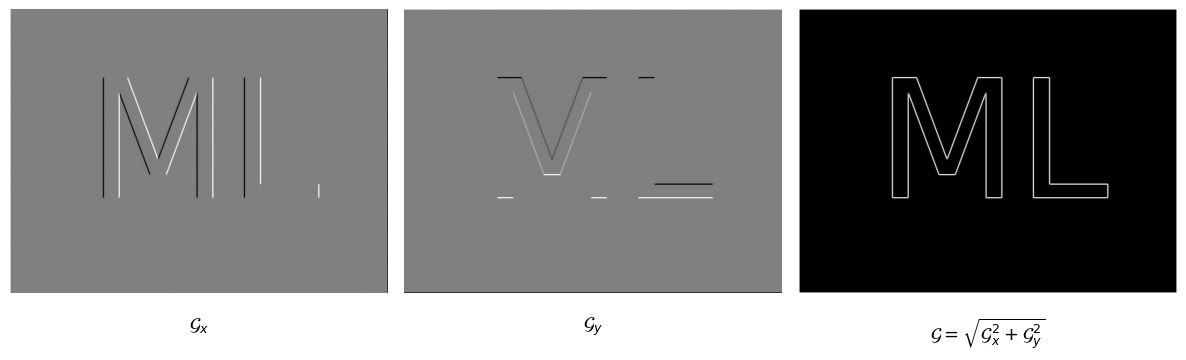

In [ ]:
# vertical kernel
v = torch.tensor([[[[1., 0., -1.],
                    [2., 0., -2.],
                    [1., 0., -1.]]]])

# horizontal kernel
h = torch.tensor([[[[ 1.,  2.,  1.],
                    [ 0.,  0.,  0.],
                    [-1., -2., -1.]]]])

# apply the convolution
kernels = torch.cat([v, h], dim=0)
kernels = kernels.flip(dims=(-2, -1))

conv = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
conv.weight = nn.Parameter(kernels, requires_grad=False)

maps = conv(x)
G_x = maps[:, 0:1]
G_y = maps[:, 1:2]

# combine the resulting feature maps into the Sobel filter
G = torch.sqrt(G_x**2 + G_y**2)

# plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
outputs = [G_x, G_y, G]
labels = [r"$\mathcal{G}_x$", r"$\mathcal{G}_y$", r"$\mathcal{G}=\sqrt{\mathcal{G}_x^2+\mathcal{G}_y^2}$"]

for ax, output, label in zip(axes, outputs, labels):
    ax.imshow(output[0, 0].detach(), cmap="gray")
    ax.axis("off")
    ax.text(0.5, -0.08, label, transform=ax.transAxes, ha="center", va="top", fontsize=13)

plt.tight_layout()
plt.savefig("output/Sobelfilter.png", dpi=100)
plt.show()